In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Load All Tickers

In [2]:
TICKERS = ['QQQ', 'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'TSLA', 'NFLX', 'INTC']
DATA_PATH = '../data/raw/'

def load_ticker(ticker):
    path = os.path.join(DATA_PATH, f'{ticker}.csv')
    df = pd.read_csv(path, parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['Ticker'] = ticker
    return df

# Load all
raw_data = {ticker: load_ticker(ticker) for ticker in TICKERS}

# Quick check
for ticker, df in raw_data.items():
    print(f"{ticker}: {df.shape} | {df['Date'].min().date()} → {df['Date'].max().date()}")

QQQ: (5301, 8) | 1999-03-10 → 2020-04-01
AAPL: (9909, 8) | 1980-12-12 → 2020-04-01
MSFT: (8584, 8) | 1986-03-13 → 2020-04-01
NVDA: (5334, 8) | 1999-01-22 → 2020-04-01
AMZN: (5758, 8) | 1997-05-15 → 2020-04-01
GOOGL: (3932, 8) | 2004-08-19 → 2020-04-01
TSLA: (2457, 8) | 2010-06-29 → 2020-04-01
NFLX: (4496, 8) | 2002-05-23 → 2020-04-01
INTC: (10098, 8) | 1980-03-17 → 2020-04-01


Check for Missing Values

In [3]:
print("=== Missing Values Check ===\n")
for ticker, df in raw_data.items():
    missing = df.isnull().sum().sum()
    print(f"{ticker}: {missing} missing values")

=== Missing Values Check ===

QQQ: 0 missing values
AAPL: 0 missing values
MSFT: 0 missing values
NVDA: 6 missing values
AMZN: 0 missing values
GOOGL: 0 missing values
TSLA: 0 missing values
NFLX: 0 missing values
INTC: 0 missing values


Visualize Adjusted Close Prices

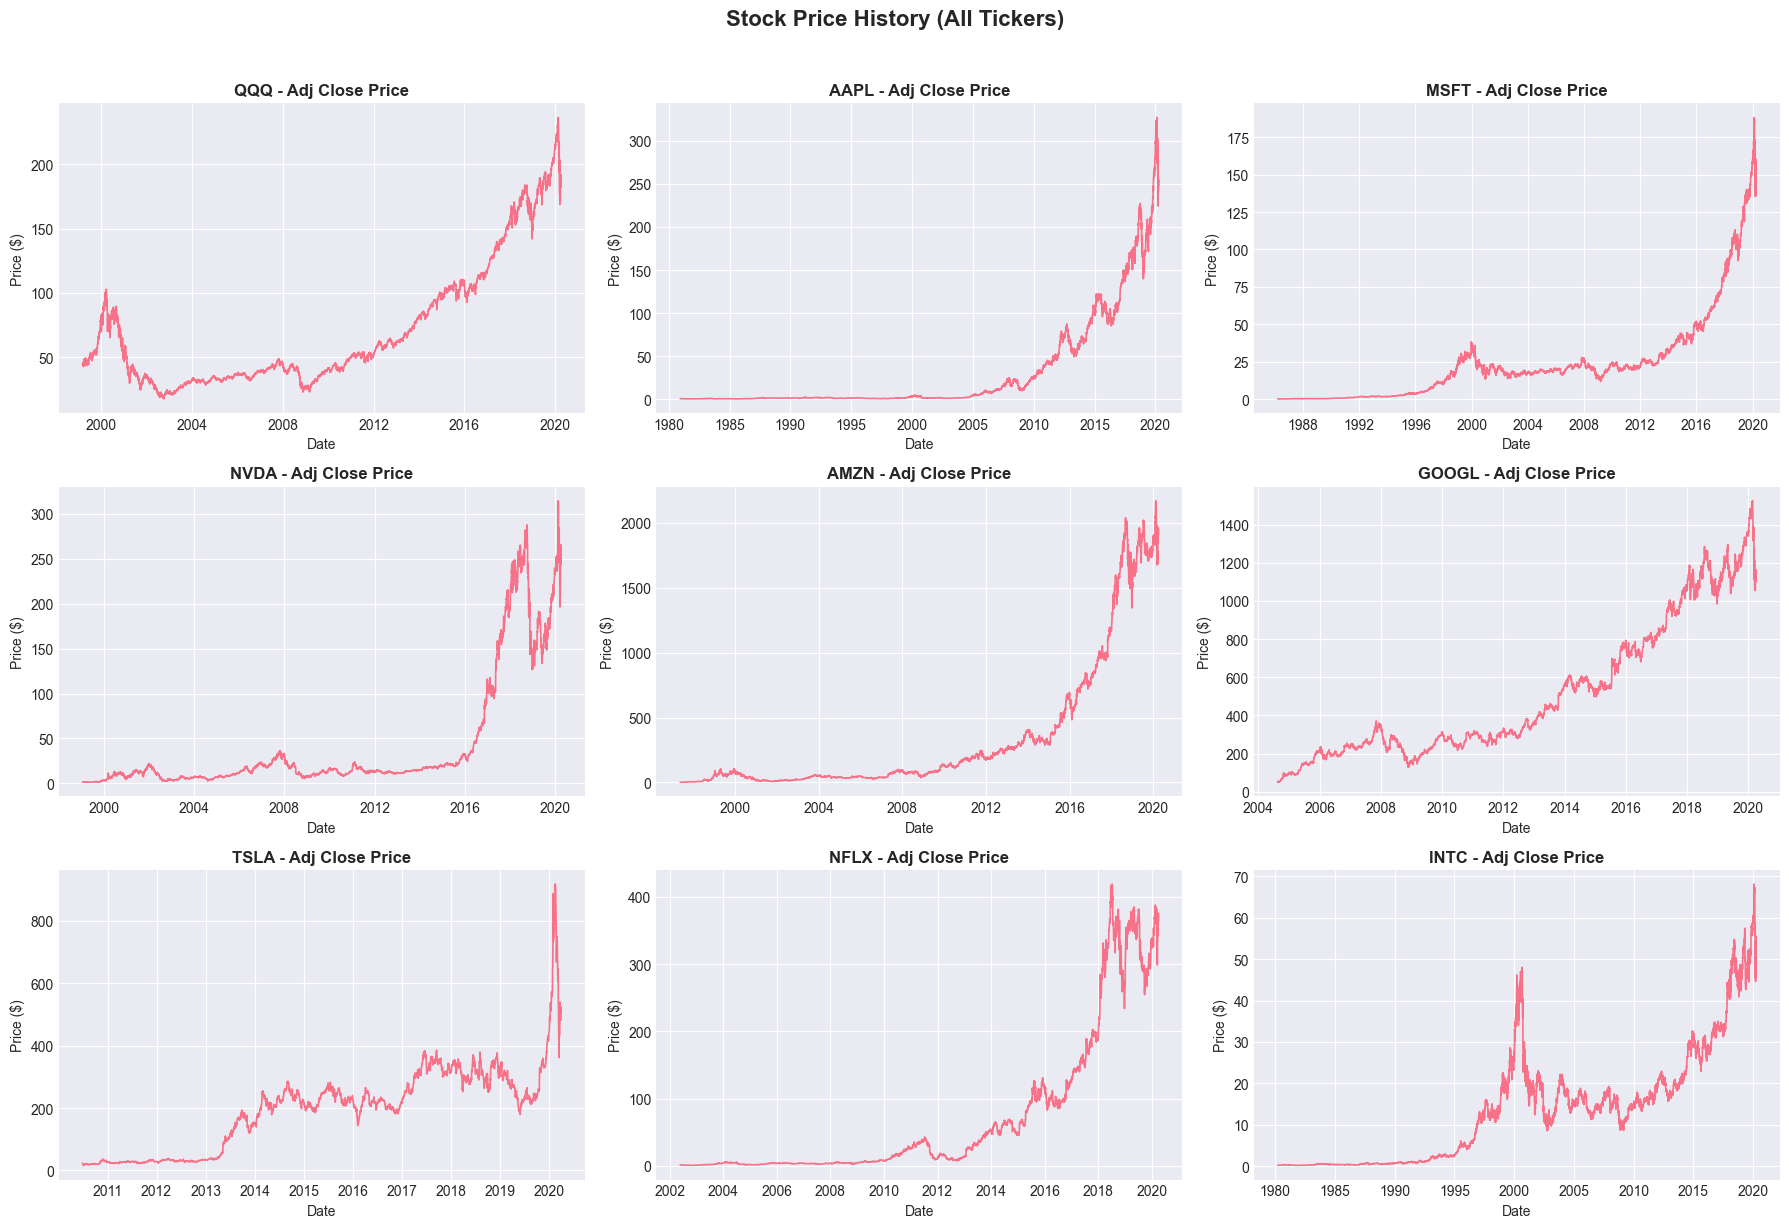

✅ Plot saved!


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df = raw_data[ticker]
    axes[i].plot(df['Date'], df['Adj Close'], linewidth=1.2)
    axes[i].set_title(f'{ticker} - Adj Close Price', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price ($)')

plt.suptitle('Stock Price History (All Tickers)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

Visualize Volume

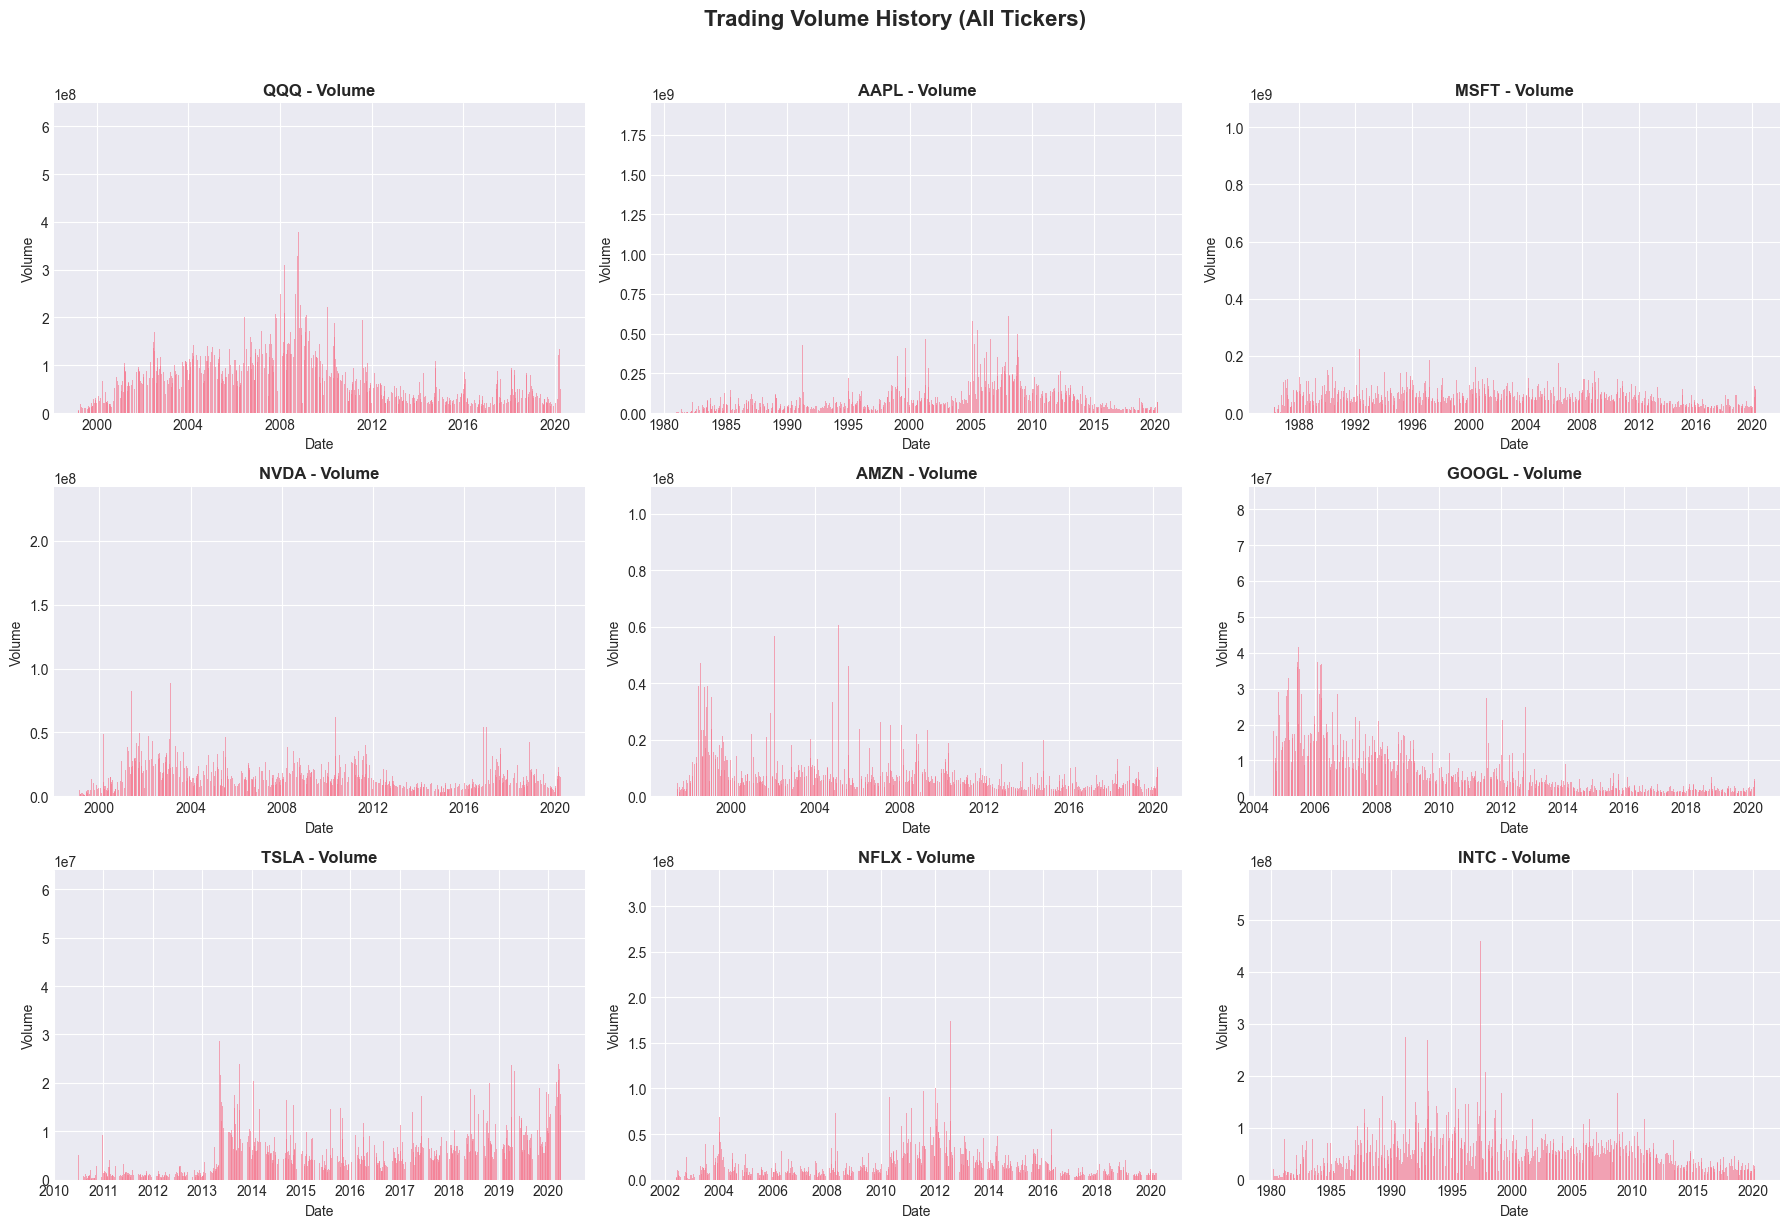

✅ Plot saved!


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df = raw_data[ticker]
    axes[i].bar(df['Date'], df['Volume'], alpha=0.6, width=1.5)
    axes[i].set_title(f'{ticker} - Volume', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Volume')

plt.suptitle('Trading Volume History (All Tickers)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/02_volume_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

 Daily Returns Distribution

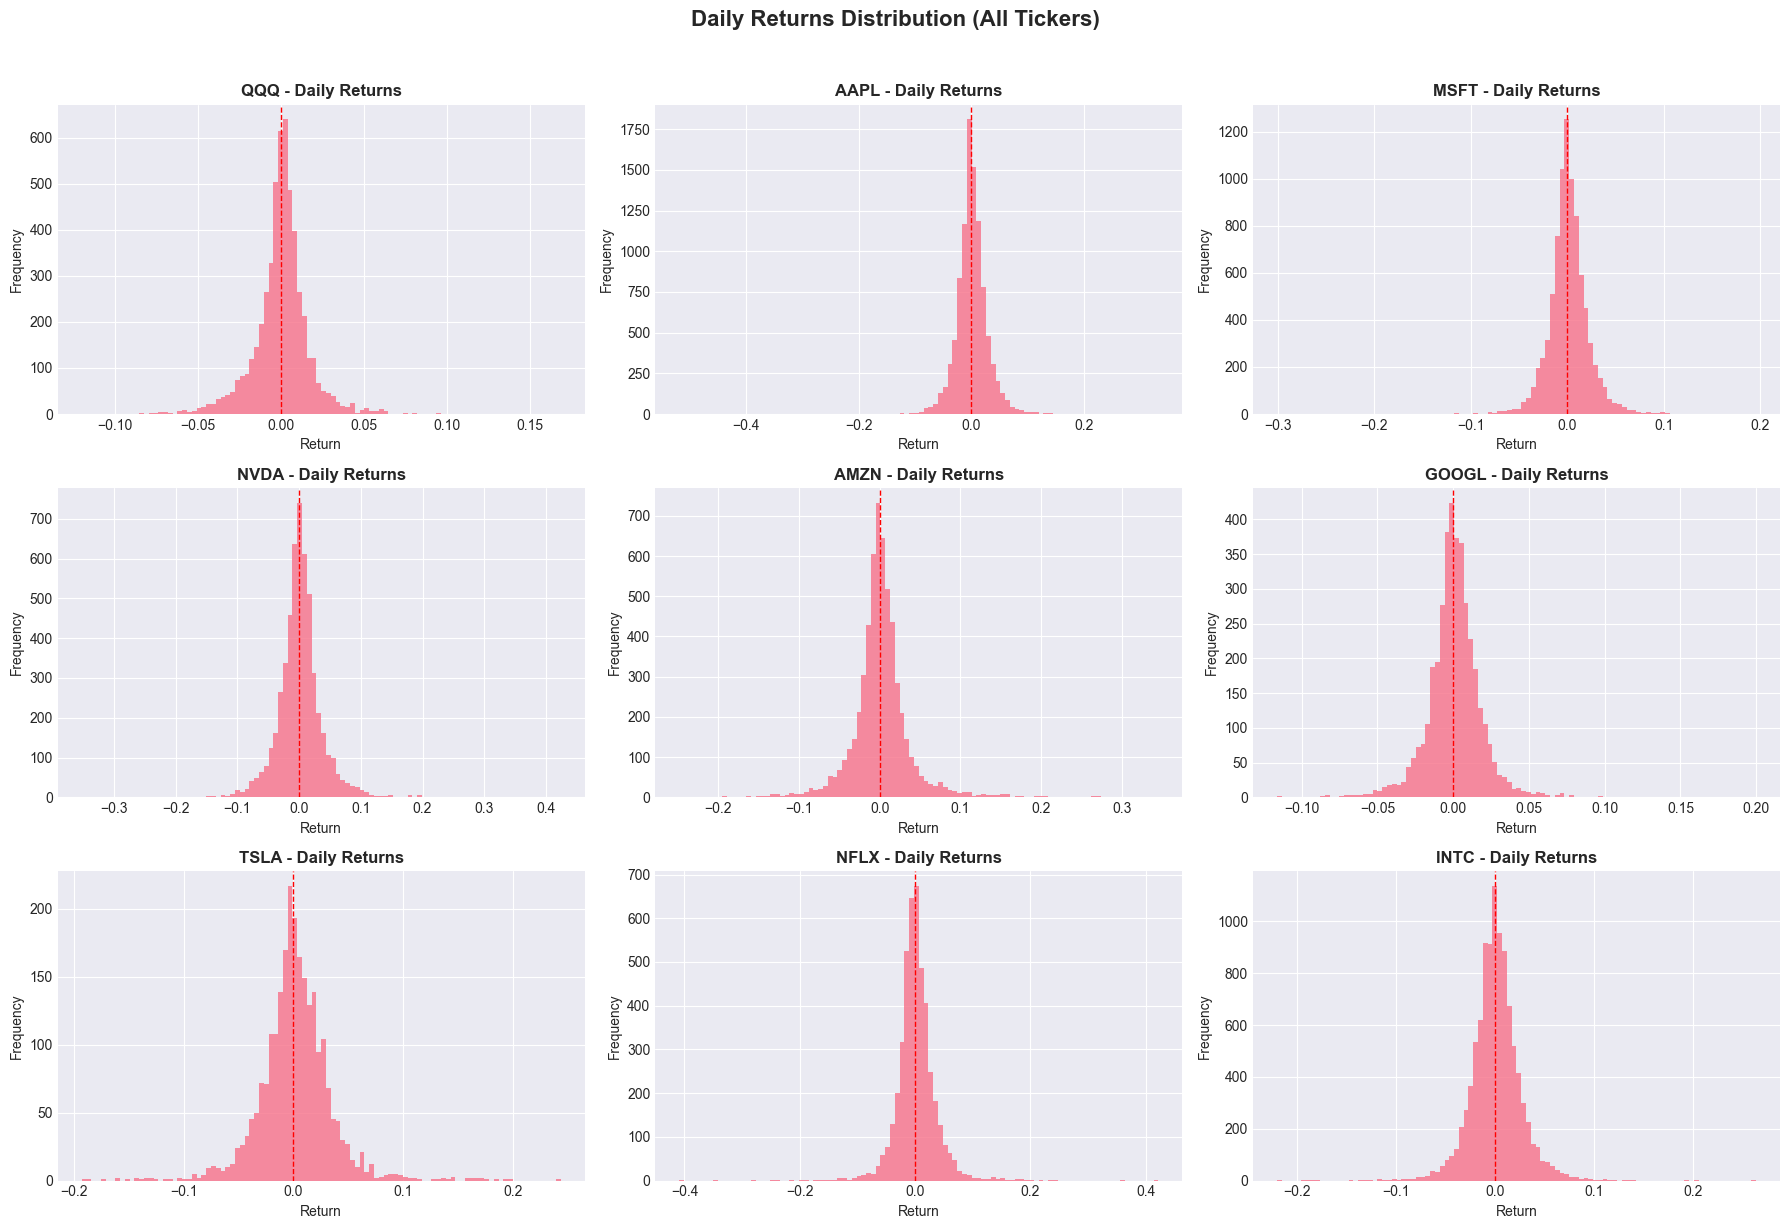

✅ Plot saved!


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    df = raw_data[ticker].copy()
    df['Return'] = df['Adj Close'].pct_change()
    axes[i].hist(df['Return'].dropna(), bins=100, edgecolor='none', alpha=0.8)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f'{ticker} - Daily Returns', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Return')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Daily Returns Distribution (All Tickers)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/plots/03_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

 Save Cleaned Data 

In [7]:
# Filter to our study period and save combined
all_dfs = []
for ticker, df in raw_data.items():
    df = df.copy()
    df['Return'] = df['Adj Close'].pct_change()
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
combined = combined[combined['Date'] >= '2018-01-01']  # our study period

combined.to_csv('../data/processed/combined_stocks.csv', index=False)
print(f"✅ Combined dataset saved! Shape: {combined.shape}")
print(f"Date range: {combined['Date'].min().date()} → {combined['Date'].max().date()}")
print(f"Tickers: {combined['Ticker'].unique()}")

✅ Combined dataset saved! Shape: (5094, 9)
Date range: 2018-01-02 → 2020-04-01
Tickers: <StringArray>
['QQQ', 'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'TSLA', 'NFLX', 'INTC']
Length: 9, dtype: str
